# Week 9 Integrative Assignment: CloudMetrics Quarterly Review

**ISM4641 - Python for Business Analytics**  
**Due Date:** March 15th

**Points:** 100 points

---

## The Story

**Wednesday, 2:15 PM**

Elena Rodriguez checks her calendar and feels her stomach drop. The Quarterly Business Review (QBR) with the executive team is Friday at 10 AM—less than 48 hours away. As the Data Analyst at **CloudMetrics**, a B2B SaaS company providing analytics software to enterprise clients, she's responsible for preparing the visual presentation of company performance.

Her manager, James Park (Director of Business Intelligence), appears at her desk looking frazzled.

*"Elena, we have a problem. The BI dashboard platform we use for executive presentations crashed, and their support says it won't be back online until next week. The CEO still expects a polished QBR presentation with all the usual visualizations."*

*"I know you've been learning Python. Can you recreate the key visualizations we need? The data is all in our systems—I just need someone who can make it look professional without the dashboard tool."*

Elena opens her laptop. She has the data exports, she has Python, and she has matplotlib. *"I'll make it happen."*

---

## Your Mission

You are Elena. Use Matplotlib to create professional visualizations for the executive QBR presentation. Your charts need to be clear, informative, and ready for the C-suite.

**Skills you'll apply:**
- Line charts for trend analysis
- Bar charts for comparisons
- Scatter plots for relationships
- Pie charts for proportions
- Histograms for distributions
- Multi-chart dashboards using subplots
- Professional styling and formatting

---

## Assignment Requirements

1. Complete all sections of this notebook
2. All visualizations must be properly labeled (titles, axes, legends)
3. Use professional styling appropriate for executive presentations
4. Include your video walkthrough (3-10 minutes)

**Video Walkthrough:** Present your visualizations as if walking the CEO through the QBR slides. See the Feb 7th "Video and Assignment Guidance" announcement for the required format.

---

## Student Information

**Name:** Luis Vieira  
**USF ID:** U18773984  
**Date:** March 15th

In [1]:
# ============================================================
# DATA GENERATION — Just run this cell!
# This creates all the datasets you'll visualize below.
# You do NOT need to understand or modify this code.
# After running, scroll down to see the variables available.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# Set default figure style for professional look
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(9641)

# CloudMetrics company colors
BRAND_BLUE = '#2E86AB'
BRAND_ORANGE = '#F18F01'
BRAND_GREEN = '#048A81'
BRAND_RED = '#C73E1D'
BRAND_PURPLE = '#6B2D5C'

# Generate Monthly Revenue Data (18 months: Jul 2023 - Dec 2024)
_month_dates = pd.date_range('2023-07-01', '2024-12-01', freq='MS')
month_labels = _month_dates.strftime('%b %Y').tolist()

# Revenue shows growth with seasonality
base_revenue = 850000
growth_rate = 0.04  # 4% monthly growth
monthly_revenue = []
for i in range(18):
    seasonal = 1 + 0.1 * np.sin(2 * np.pi * i / 12)  # Seasonality
    noise = np.random.uniform(-0.03, 0.03)  # Random variation
    revenue = base_revenue * ((1 + growth_rate) ** i) * seasonal * (1 + noise)
    monthly_revenue.append(round(revenue, 2))

# MRR (Monthly Recurring Revenue) - more stable, core business
monthly_mrr = [round(r * np.random.uniform(0.75, 0.85), 2) for r in monthly_revenue]

# Customer Count Data
starting_customers = 180
customer_counts = [starting_customers]
for i in range(17):
    new = np.random.randint(8, 18)
    churned = np.random.randint(2, 6)
    customer_counts.append(customer_counts[-1] + new - churned)

# Revenue by Product Line (Q4 2024)
products = ['Analytics Pro', 'Dashboard Suite', 'Data Connect', 'API Services', 'Custom Solutions']
product_revenue = [520000, 380000, 290000, 180000, 130000]

# Revenue by Industry
industries = ['Financial Services', 'Healthcare', 'Retail', 'Technology', 'Manufacturing', 'Other']
industry_revenue = [410000, 340000, 280000, 250000, 150000, 70000]

# Customer Satisfaction Scores (0-100)
csat_scores = np.random.normal(78, 12, 200)
csat_scores = np.clip(csat_scores, 0, 100)  # Keep within 0-100

# Sales Rep Performance (Q4)
sales_reps = ['Sarah K.', 'Mike R.', 'Lisa T.', 'James W.', 'Amy C.', 'Tom B.']
deals_closed = [28, 24, 22, 19, 17, 15]
revenue_generated = [680000, 590000, 520000, 410000, 380000, 320000]

# Support Ticket Volume by Category
ticket_categories = ['Technical', 'Billing', 'Feature Request', 'Training', 'Other']
ticket_counts = [245, 89, 156, 112, 48]

# Churn Risk Data (scatter plot)
n_customers_sample = 50
engagement_score = np.random.uniform(20, 100, n_customers_sample)
months_as_customer = np.random.randint(1, 36, n_customers_sample)
# Higher engagement = less likely to churn
churn_probability = 100 - engagement_score + np.random.normal(0, 10, n_customers_sample)
churn_probability = np.clip(churn_probability, 5, 95)

print("CloudMetrics Q4 2024 Data Loaded Successfully!")
print(f"\n  Revenue data: {len(monthly_revenue)} months (Jul 2023 - Dec 2024)")
print(f"  Customer count: {customer_counts[-1]} active customers")
print(f"  Product lines: {len(products)}")
print(f"  CSAT surveys: {len(csat_scores)} responses")
print(f"  Sales reps: {len(sales_reps)}")
print(f"\nVariables you'll use: month_labels, monthly_revenue, monthly_mrr,")
print(f"  customer_counts, products, product_revenue, industries, industry_revenue,")
print(f"  csat_scores, sales_reps, deals_closed, revenue_generated,")
print(f"  ticket_categories, ticket_counts, engagement_score, churn_probability,")
print(f"  months_as_customer, BRAND_BLUE/ORANGE/GREEN/RED/PURPLE")

CloudMetrics Q4 2024 Data Loaded Successfully!

  Revenue data: 18 months (Jul 2023 - Dec 2024)
  Customer count: 329 active customers
  Product lines: 5
  CSAT surveys: 200 responses
  Sales reps: 6

Variables you'll use: month_labels, monthly_revenue, monthly_mrr,
  customer_counts, products, product_revenue, industries, industry_revenue,
  csat_scores, sales_reps, deals_closed, revenue_generated,
  ticket_categories, ticket_counts, engagement_score, churn_probability,
  months_as_customer, BRAND_BLUE/ORANGE/GREEN/RED/PURPLE


---

## Part 1: Revenue Trend Analysis (20 points)

James explains: *"The CEO always starts with the revenue slide. She wants to see the trend over the past 18 months, with both total revenue and MRR shown. Make it clear if we're on an upward trajectory."*

**Your Task:**
Create a professional line chart showing:
1. Total Monthly Revenue (one line)
2. Monthly Recurring Revenue/MRR (second line)
3. Proper formatting:
   - Clear title stating what the chart shows
   - Y-axis in millions or with currency formatting
   - Legend distinguishing the two lines
   - Grid for readability
   - X-axis labels rotated if needed
4. Use CloudMetrics brand colors
5. Add a text annotation highlighting Q4 2024 performance

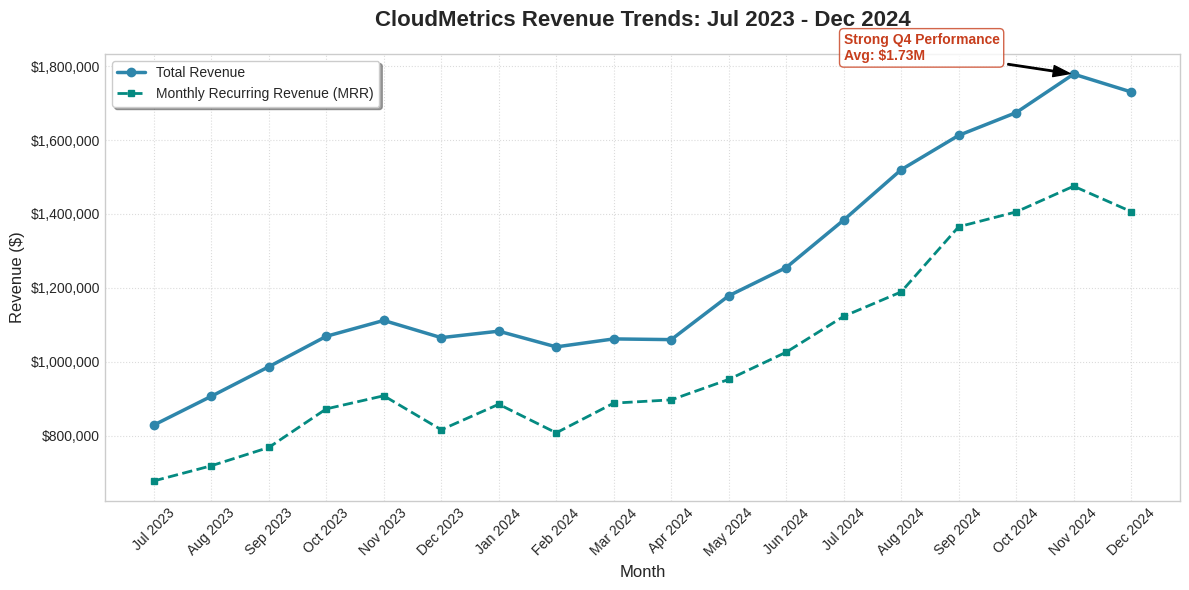

In [2]:
# Part 1: Revenue Trend Analysis

# Create the figure
# Recommended size: (12, 6)
plt.figure(figsize=(12, 6))

# Plot Total Revenue and MRR
# Use different line styles and markers to distinguish them
plt.plot(month_labels,
         monthly_revenue,
         label='Total Revenue',
         color=BRAND_BLUE,
         linewidth=2.5, marker='o', markersize=6)
plt.plot(month_labels,
         monthly_mrr,
         label='Monthly Recurring Revenue (MRR)',
         color=BRAND_GREEN, linewidth=2, linestyle='--', marker='s', markersize=4)

# Add title, labels, legend
plt.title('CloudMetrics Revenue Trends: Jul 2023 - Dec 2024',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.legend(frameon=True, shadow=True)

# Format y-axis (currency or millions)
# Hint: You can divide values by 1_000_000 before plotting,
#   or use plt.gca().yaxis.set_major_formatter(...) — ask Gemini for help
from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Rotate x-axis labels for readability
# Hint: plt.xticks(rotation=45)
plt.xticks(rotation=45)

# Add grid for readability
plt.grid(True, linestyle=':', alpha=0.7)

# Add annotation for Q4 2024
# Hint: Use plt.annotate() or plt.text()
# Q4 includes the last three months: Oct, Nov, Dec 2024
q4_avg = np.mean(monthly_revenue[-3:])
plt.annotate(f'Strong Q4 Performance\nAvg: ${q4_avg/1e6:.2f}M',
             xy=(month_labels[-2], monthly_revenue[-2]),
             xytext=(month_labels[-6], monthly_revenue[-1] * 1.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', color=BRAND_RED,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=BRAND_RED, alpha=0.8))

# Show the plot
plt.tight_layout()
plt.show()

---

## Part 2: Customer Growth and Composition (20 points)

*"Next, the board wants to see our customer growth alongside our revenue mix,"* James continues. *"Can you create side-by-side charts showing customer count growth AND how our revenue breaks down by product line?"*

**Your Task:**
Create a figure with 2 subplots (1 row, 2 columns):

**Left subplot - Customer Growth (Line chart):**
- Show customer count over the 18-month period
- Add markers at each data point
- Include a horizontal line showing the starting point for reference

**Right subplot - Revenue by Product (Pie chart):**
- Show Q4 2024 revenue breakdown by product line
- Display percentages on the chart
- "Explode" the largest segment slightly
- Use brand colors

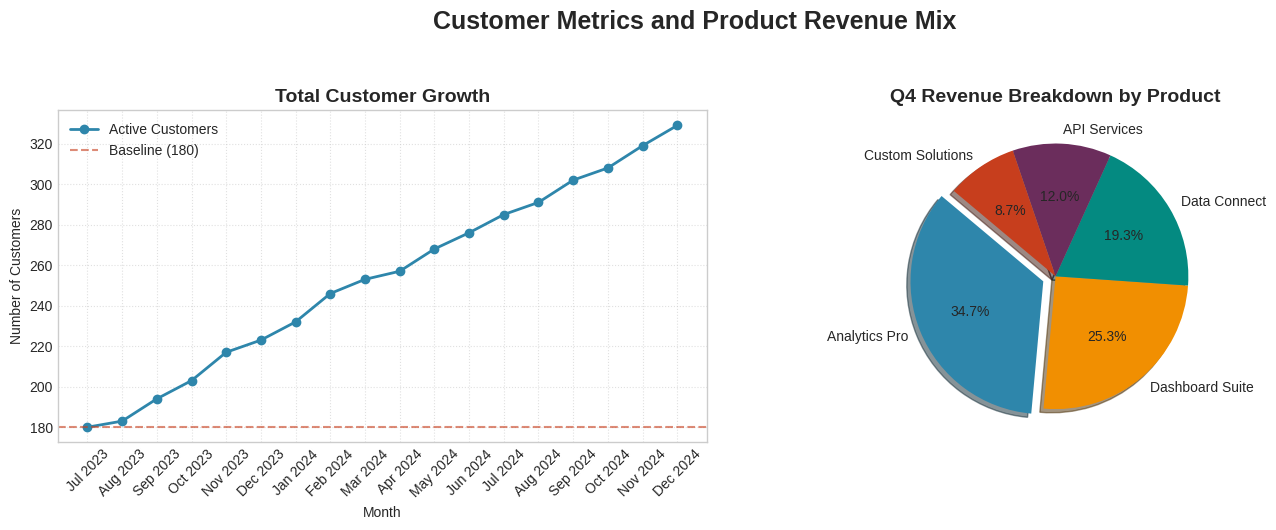

In [3]:
# Part 2: Customer Growth and Composition

# Create figure with 2 subplots
# Recommended size: (14, 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: Customer Growth (Line chart)
# Hint: axes[0].plot(...)
axes[0].plot(month_labels,
             customer_counts,
             color=BRAND_BLUE,
             marker='o', linewidth=2, label='Active Customers')
# Hint: axes[0].axhline(...) for the starting point reference line
axes[0].axhline(y=customer_counts[0],
                color=BRAND_RED,
                linestyle='--', alpha=0.6, label=f'Baseline ({customer_counts[0]})')
axes[0].set_title('Total Customer Growth', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Right subplot: Revenue by Product (Pie chart)
# Hint: axes[1].pie(...)
colors = [BRAND_BLUE, BRAND_ORANGE, BRAND_GREEN, BRAND_PURPLE, BRAND_RED]
explode = [0.1 if rev == max(product_revenue) else 0 for rev in product_revenue]

axes[1].pie(product_revenue,
         labels=products,
         autopct='%1.1f%%',
         startangle=140,
         colors=colors,
         explode=explode,
         shadow=True,
         textprops={'fontsize': 10})
axes[1].set_title('Q4 Revenue Breakdown by Product', fontsize=14, fontweight='bold')

# Add overall title for the figure
# Hint: fig.suptitle(...)
fig.suptitle('Customer Metrics and Product Revenue Mix', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

---

## Part 3: Sales Team Performance (20 points)

*"The CFO always asks about sales productivity,"* James notes. *"Create charts comparing our sales reps—both the number of deals they closed AND the revenue they generated. It should be easy to see who's bringing in the most value."*

**Your Task:**
Create a figure with 2 subplots (1 row, 2 columns):

**Left subplot - Deals Closed (Bar chart):**
- Horizontal bar chart showing deals closed per rep
- Use the same rep ordering as the right chart (sort by revenue)
- Add value labels on the bars
- Use a brand color

**Right subplot - Revenue Generated (Bar chart):**
- Horizontal bar chart showing revenue per rep
- Sort by revenue (highest at top)
- Format revenue as currency on value labels
- Use a different brand color

Requirements:
- Both charts should have the same rep ordering (sort by revenue)
- Professional colors and styling
- Clear titles on each subplot

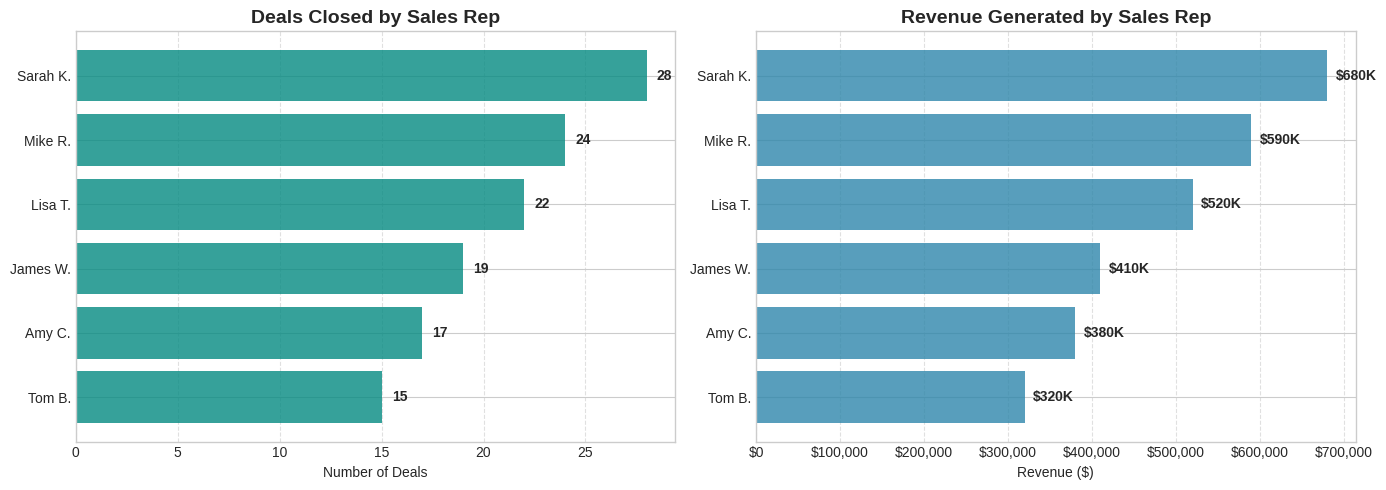

In [4]:
# Part 3: Sales Team Performance

# Sort reps by revenue (ascending) — barh draws bottom-to-top,
# so ascending order puts the highest value bar at the TOP of the chart.
sorted_data = sorted(zip(revenue_generated, sales_reps, deals_closed))
sorted_rev, sorted_reps, sorted_deals = zip(*sorted_data)

# Create figure with 2 subplots (1 row, 2 columns)
# Recommended size: (14, 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: Deals Closed (horizontal bar chart)
# Hint: axes[0].barh(sorted_reps, sorted_deals, ...)
bars1 = axes[0].barh(sorted_reps, sorted_deals, color=BRAND_GREEN, alpha=0.8)
axes[0].set_title('Deals Closed by Sales Rep', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Deals')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Add value labels on bars
for bar in bars1:
    width = bar.get_width()
    axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
                 va='center', fontweight='bold')

# Right subplot: Revenue Generated (horizontal bar chart)
# Hint: axes[1].barh(sorted_reps, sorted_rev, ...)
bars2 = axes[1].barh(sorted_reps, sorted_rev, color=BRAND_BLUE, alpha=0.8)
axes[1].set_title('Revenue Generated by Sales Rep', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

# Add value labels formatted as currency
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 10000, bar.get_y() + bar.get_height()/2, f'${width/1e3:.0f}K',
                 va='center', fontweight='bold')

# Formatting the X-axis for currency
from matplotlib.ticker import StrMethodFormatter
axes[1].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

---

## Part 4: Customer Health Analysis (20 points)

*"The board is concerned about churn,"* James explains. *"We need two visualizations: one showing our CSAT score distribution, and one showing the relationship between customer engagement and churn risk. This will help justify our customer success budget."*

**Your Task:**
Create a figure with 2 subplots (1 row, 2 columns):

**Left subplot - CSAT Distribution (Histogram):**
- Show distribution of customer satisfaction scores
- Add vertical lines for mean and median using `axvline()`
- Use appropriate number of bins (15-25)
- Add legend explaining the reference lines

**Right subplot - Engagement vs Churn Risk (Scatter plot):**
- X-axis: Engagement Score
- Y-axis: Churn Probability (%)
- Color points by `months_as_customer` to show tenure (use the `c` parameter in `plt.scatter()`)
- Add a trend line using `np.polyfit()` and `np.poly1d()`
- Add a colorbar to explain the color scale

**Note:** The colorbar is a new technique — use Gemini to help you with `plt.colorbar()`. This is exactly the kind of thing you'd look up on the job.

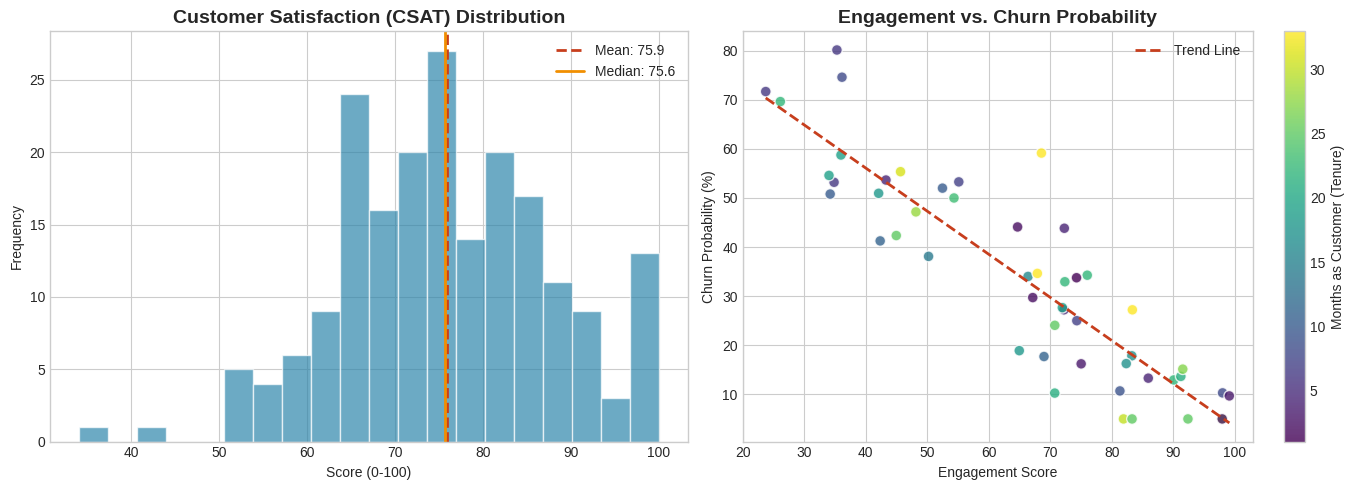

In [5]:
# Part 4: Customer Health Analysis

# Create figure with 2 subplots
# Recommended size: (14, 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: CSAT Distribution (Histogram)
# Hint: axes[0].hist(csat_scores, bins=20, ...)
axes[0].hist(csat_scores, bins=20, color=BRAND_BLUE, alpha=0.7, edgecolor='white')
axes[0].set_title('Customer Satisfaction (CSAT) Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Frequency')

# Add mean and median lines
# Hint: axes[0].axvline(x=np.mean(csat_scores), ...)
mean_csat = np.mean(csat_scores)
median_csat = np.median(csat_scores)
axes[0].axvline(mean_csat,
                color=BRAND_RED, linestyle='--', linewidth=2, label=f'Mean: {mean_csat:.1f}')
axes[0].axvline(median_csat,
                color=BRAND_ORANGE, linestyle='-', linewidth=2, label=f'Median: {median_csat:.1f}')
axes[0].legend()

# Right subplot: Engagement vs Churn Risk (Scatter)
# Hint: scatter = axes[1].scatter(engagement_score, churn_probability,
#                                  c=months_as_customer, cmap='viridis')
scatter = axes[1].scatter(engagement_score, churn_probability,
                         c=months_as_customer, cmap='viridis', alpha=0.8, s=60, edgecolors='w')
axes[1].set_title('Engagement vs. Churn Probability', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Engagement Score')
axes[1].set_ylabel('Churn Probability (%)')

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Months as Customer (Tenure)')

# Add trend line
# Hint: x_sorted = np.sort(engagement_score)  — sorted x needed for a smooth line
z = np.polyfit(engagement_score, churn_probability, 1)
trend = np.poly1d(z)
x_range = np.linspace(engagement_score.min(), engagement_score.max(), 100)
axes[1].plot(x_range,
             trend(x_range), color=BRAND_RED, linestyle='--', linewidth=2, label='Trend Line')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Part 5: Executive Dashboard (20 points)

*"Finally,"* James says, *"we need a single-page executive dashboard that captures all the key metrics at a glance. This will be the summary slide at the end of the presentation."*

**Your Task:**
Create a comprehensive 2x2 dashboard with these four visualizations:

1. **Top-left:** Revenue trend (simplified line chart, last 6 months only)
2. **Top-right:** Revenue by Industry (horizontal bar chart)
3. **Bottom-left:** Support Tickets by Category (pie chart)
4. **Bottom-right:** Key Metrics summary (text-based panel)
   - Include: Total Q4 Revenue, Customer Count, Average CSAT, MRR Growth %

Requirements:
- Professional, consistent styling across all charts
- Clear main title for the dashboard using `fig.suptitle()`
- Each subplot has its own title
- Brand colors throughout
- Tight layout to prevent overlap

**Hint for the text panel:** You can turn a subplot into a text-only panel by calling `ax.axis('off')` to hide the axes, then using `ax.text(0.5, 0.5, "your text", ...)` to place text in the center. Use `\n` for line breaks. Ask Gemini for help formatting this if needed.

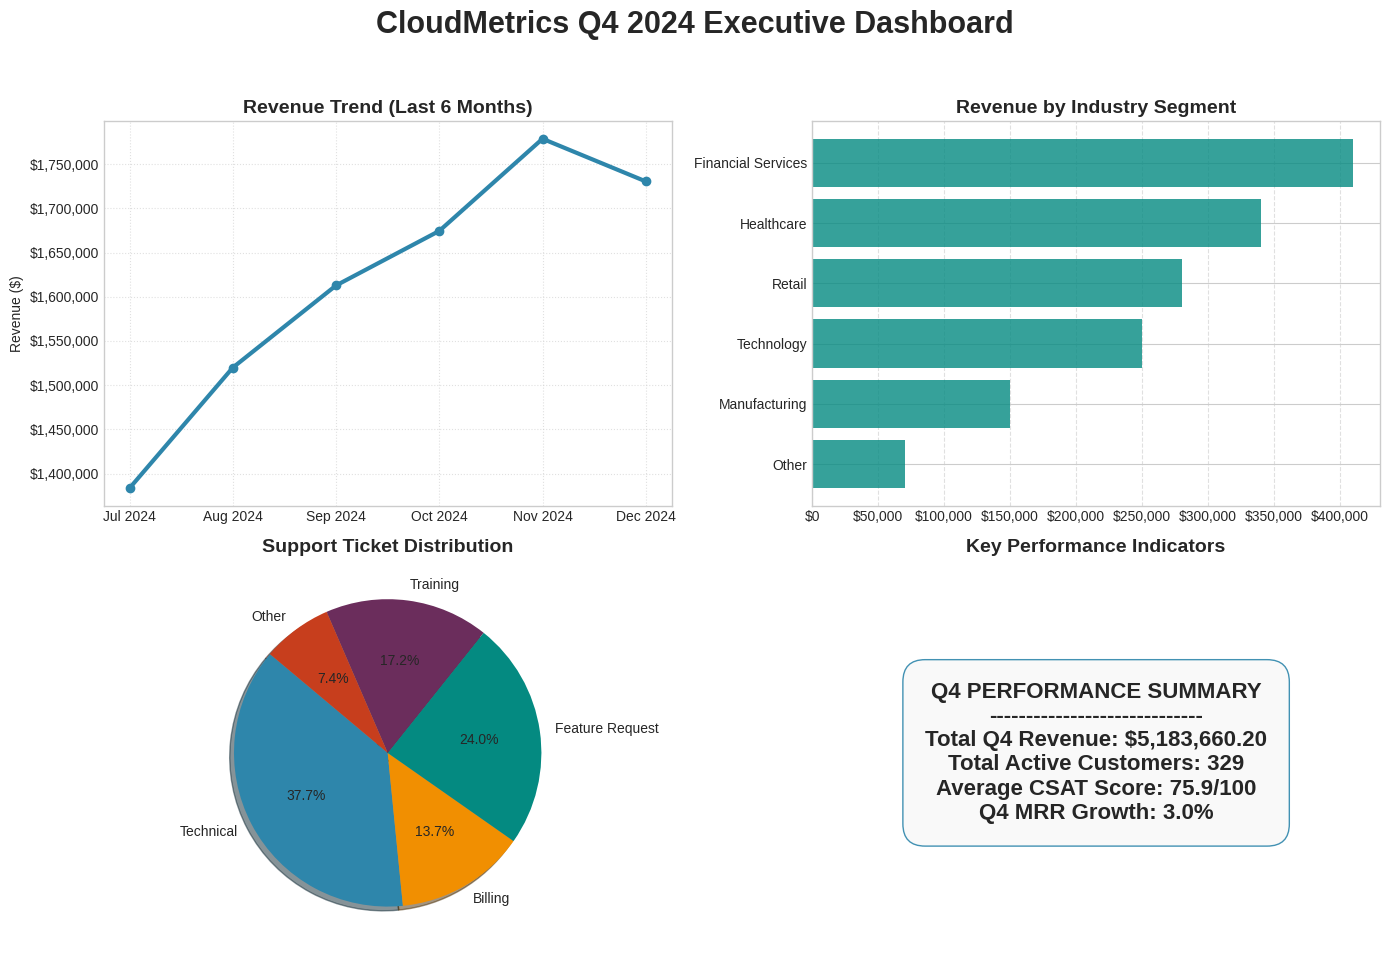

In [6]:
# Part 5: Executive Dashboard

# Create 2x2 subplot figure
# Recommended size: (14, 10)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate key metrics for the summary panel
q4_revenue = sum(monthly_revenue[-3:])  # Last 3 months
final_customer_count = customer_counts[-1]
avg_csat = np.mean(csat_scores)
mrr_growth = (monthly_mrr[-1] - monthly_mrr[-4]) / monthly_mrr[-4] * 100  # Q4 growth

# Top-left: Revenue Trend (last 6 months)
axes[0, 0].plot(month_labels[-6:], monthly_revenue[-6:], color=BRAND_BLUE, marker='o', linewidth=3)
axes[0, 0].set_title('Revenue Trend (Last 6 Months)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)')
from matplotlib.ticker import StrMethodFormatter
axes[0, 0].yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Top-right: Revenue by Industry (horizontal bar)
sorted_ind = sorted(zip(industry_revenue, industries))
ind_rev, ind_names = zip(*sorted_ind)
axes[0, 1].barh(ind_names, ind_rev, color=BRAND_GREEN, alpha=0.8)
axes[0, 1].set_title('Revenue by Industry Segment', fontsize=14, fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.6)

# Bottom-left: Support Tickets (pie)
axes[1, 0].pie(ticket_counts, labels=ticket_categories, autopct='%1.1f%%',
              colors=[BRAND_BLUE, BRAND_ORANGE, BRAND_GREEN, BRAND_PURPLE, BRAND_RED],
              startangle=140, shadow=True)
axes[1, 0].set_title('Support Ticket Distribution', fontsize=14, fontweight='bold')

# Bottom-right: Key Metrics Summary (text)
axes[1, 1].axis('off')
metrics_text = (
    f"Q4 PERFORMANCE SUMMARY\n"
    f"-----------------------------\n"
    f"Total Q4 Revenue: ${q4_revenue:,.2f}\n"
    f"Total Active Customers: {final_customer_count}\n"
    f"Average CSAT Score: {avg_csat:.1f}/100\n"
    f"Q4 MRR Growth: {mrr_growth:.1f}%"
)
axes[1, 1].text(0.5, 0.5, metrics_text, transform=axes[1, 1].transAxes,
               ha='center', va='center', fontsize=16, fontweight='bold',
               bbox=dict(boxstyle='round,pad=1', fc='#f9f9f9', ec=BRAND_BLUE, alpha=0.9))
axes[1, 1].set_title('Key Performance Indicators', fontsize=14, fontweight='bold')

# Add main dashboard title
fig.suptitle('CloudMetrics Q4 2024 Executive Dashboard', fontsize=22, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---

## Epilogue

**Friday, 11:30 AM**

The QBR just ended. Elena is packing up her laptop when CEO Margaret Chen approaches her.

*"Elena, those visualizations were excellent. Clean, professional, and told the story clearly. The board was impressed—especially the customer health analysis. That scatter plot showing engagement vs. churn risk convinced them to approve the expanded customer success team."*

*"James mentioned you built all of this in Python after our dashboard platform went down. That's exactly the kind of adaptability we need. I'd like you to work with IT on building a more resilient reporting infrastructure. Are you interested?"*

Elena smiles. What started as an emergency turned into an opportunity. *"I'd love to. I have some ideas about making our reporting more automated and reliable."*

---

## Interaction Log

### AI Tool Usage
*Did you use any AI tools? If so, what for?*

[I used Gemini's Copilot for all code implementaion, as well as error correction and modifications]

### Matplotlib Functions Used
*List the key Matplotlib functions you used and briefly explain why.*

[plt.plot, plt.pie, plt.bar/plt.barh, plt.scatter, plt.hist, plt.subplots, plt.figure, legends, labels, titles and annotations are among the most used ones.]

### Design Decisions
*Explain any design choices you made to make your visualizations more professional and readable.*

[Distinct professional colors, clear labels, legends and titles, as well as simple charts were the focus on the solution of this scenario to assure stakeholders would have full understanding of visualizations.]

---

## Submission Checklist

- [x] All code cells run without errors
- [x] All five parts are completed with visualizations displayed
- [x] All charts have proper titles, axis labels, and legends
- [x] Charts use professional styling suitable for executives
- [x] Dashboard layout is clean and readable
- [x] Interaction log is completed
- [x] Video walkthrough is recorded (3-10 minutes, per Feb 7th announcement)

---
*ISM4641 Python for Business Analytics - Week 9 Integrative Assignment*